In [1]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.9.2
QuTiP version: 5.2.2


## Define experimental parameters

In [2]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.001,  
    dephasing = 0.001,      
    relaxation = 0.001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.001]
  Dephasing rate:       [0.001]
  Relaxation rate:      [0.001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\Nathan\AppData\Local\Temp\ipykernel_6424\2894009835.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


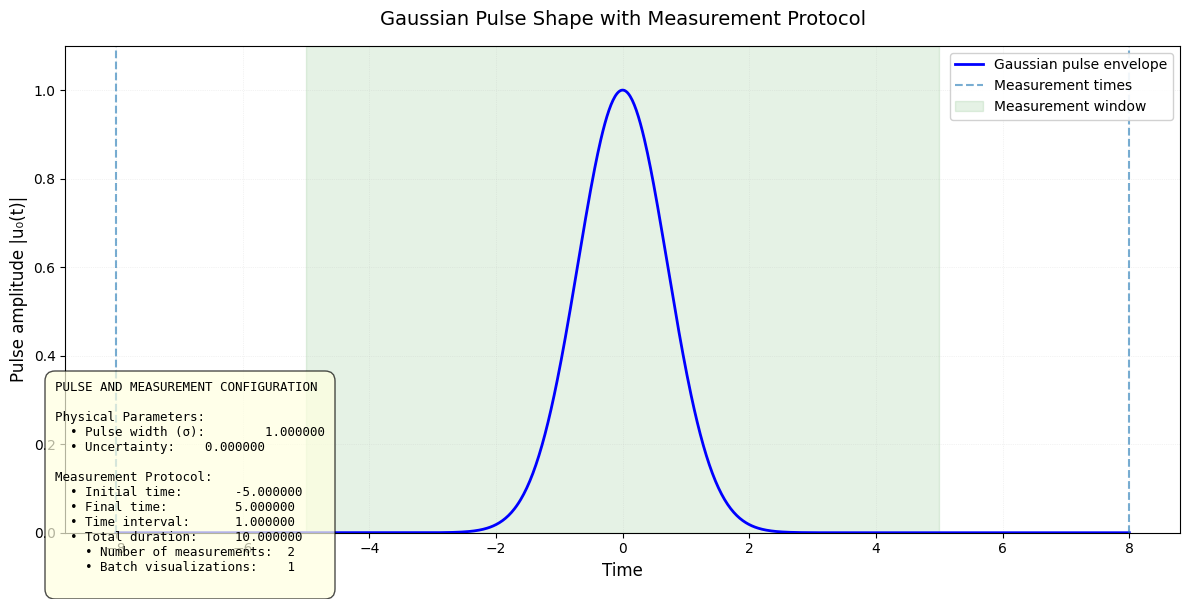

In [3]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [4]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
initial_circuit.add_layer(RZGate, parameters=0.0)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64), Array(0., dtype=float64)]
QuantumCircuit(1 qubits, 2 gates)
  0: RY[0](param=1.571)
  1: RZ[0](param=0.000)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [5]:
detection_metric = DetectionMetric(n_qubits=1, 
                                   detection_criterion = 'any excited',
                                   detection_param=(4,2))

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric:
at least 1 excitation



C:\Users\Nathan\Desktop\Quantum-sensing-QML\src\qsopt\core\loss_functions.py:274: UserWarning: 'any excited' detection criterion does not take any parameter. Value given: (4, 2). The parameter will be ignored.
  warnings.warn(f"'any excited' detection criterion does not take any parameter. Value given: {parameter}. The parameter will be ignored.")


DEBUG loss_functions:

Detection projectors built for states: ['1']
Projectors: [Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=JaxArray, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]]


## Test Single Simulation

In [6]:
results = experiment.run_simulation(debug=False, states_probabilities=True)
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 0.000000 rad (0.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.970199
     Without photon: 0.029745
     Metric:            0.940454
  State Probabilities:
     With photon:
        0: 0.029801
        1: 0.970199
     Without photon:
        0: 0.970255
        1: 0.029745
  Detection Protocol:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Confusion Matrix:
     --------------------
     True Positive:  0.970199
     False Negative: 0.029801
     --------------------
     True Negative:  0.970255
     False Positive: 0.029745
     --------------------


## Time Evolution

In [7]:
result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()

TypeError: can't multiply sequence by non-int of type 'Qobj'

## Run Optimization

In [ ]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[1, -0.8, -2], 
    num_steps=500,
    verbose=True,
    verbose_step=5,
    batch_size=1,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

In [ ]:
print(history)

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    show_confusion_matrix_summary=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [ ]:
# time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

In [ ]:
# from qsopt.utils.visualization import plot_time_interval_landscape

# fig = plot_time_interval_landscape(
#     landscape_data=time_callback,
#     exp_params=experiment.experimental_params,
#     save_path='results/time_interval_opt.pdf'
# )


## Sweep chi-gamma

In [ ]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

In [ ]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Continue Optimization From a Saved Callback

You can stop and resume optimization by saving the callback to disk and loading it back with `OptimizationCallback.load_callback`.
This restores both parameters and optimizer state (and gradients), so `hot_start=True` continues from the saved point.

In [ ]:
history.save('results/single_qubit_hotstart.npz')

loaded_history = OptimizationCallback.load_callback('results/single_qubit_hotstart.npz')

history_resumed = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    verbose=True,
    verbose_step=1,
    tolerance=1e-7,
    callback=loaded_history,
    optimizer=optax.sgd(learning_rate=0.5),
    hot_start=True,
)

print(history_resumed)

print('\n' + '-' * 80 + '\n')

# Build a fresh experiment for a clean 15-step baseline from the same initial values
baseline_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=create_ry_circuit(n_qubits=1, theta_values=[np.pi / 2]),
    final_circuit=create_ry_circuit(n_qubits=1, theta_values=[-np.pi / 2]),
    detection_metric=detection_metric,
 )

continued_callback = OptimizationCallback(save_every=1, save_best=True)
history_continued = baseline_experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=15,
    verbose=True,
    verbose_step=1,
    batch_size=1,
    tolerance=1e-7,
    callback=continued_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

print(history_continued)

m_resumed = np.array(history_resumed.history['metric'], dtype=float)
m_continued = np.array(history_continued.history['metric'], dtype=float)
n_overlap = min(len(m_resumed), len(m_continued))
print(f'len(resumed)={len(m_resumed)}, len(continued)={len(m_continued)}')
print('max_abs_metric_diff_on_overlap=', float(np.max(np.abs(m_resumed[:n_overlap] - m_continued[:n_overlap]))))

In [ ]:
# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_resumed,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_continued,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

In [ ]:
import numpy as np

res_epochs = np.array(history_resumed.history.get('epochs', []), dtype=int)
res_metric = np.array(history_resumed.history.get('metric', []), dtype=float)

cont_epochs = np.array(history_continued.history.get('epochs', []), dtype=int)
cont_metric = np.array(history_continued.history.get('metric', []), dtype=float)

print('resumed_epochs:', res_epochs.tolist())
print('resumed_metric:', res_metric.tolist())
print('continued_epochs:', cont_epochs.tolist())
print('continued_metric:', cont_metric.tolist())

n = min(len(res_metric), len(cont_metric))
print('overlap_len:', n)
if n > 0:
    diffs = np.abs(res_metric[:n] - cont_metric[:n])
    print('overlap_abs_diff:', diffs.tolist())
    print('max_abs_diff_overlap:', float(np.max(diffs)))

print('history_epochs:', history.history.get('epochs', []))
print('history_metric:', history.history.get('metric', []))